In [26]:
#Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [27]:
#Cell 2: Load Dataset
df = pd.read_csv(r"C:\Users\SURANJANA MAJUMDAR\OneDrive\Desktop\Credit Card Fraud Detection\.gitignore\archive.zip")

In [28]:
#Cell 3: Display Dataset
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [29]:
#Cell 4: Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [30]:
#Cell 5: Check Missing Values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [31]:
#Cell 6: Check Class Distribution
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

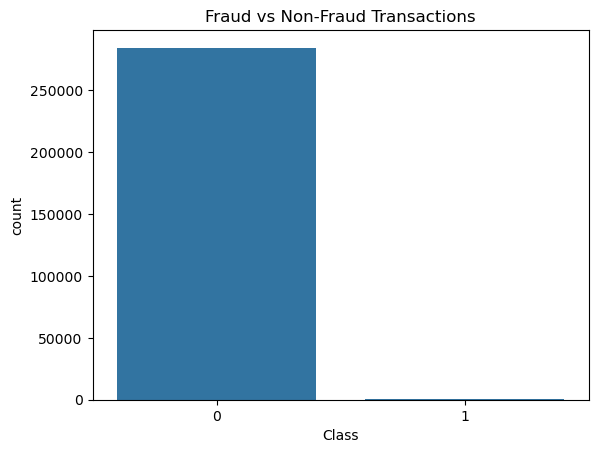

In [32]:
#Cell 7: Visualize Fraud vs Non-Fraud
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [33]:
#Cell 8: Percentage of Fraud Cases
fraud = df['Class'].value_counts()[1]
normal = df['Class'].value_counts()[0]
print("Fraud Percentage:", (fraud/(fraud+normal))*100)

Fraud Percentage: 0.1727485630620034


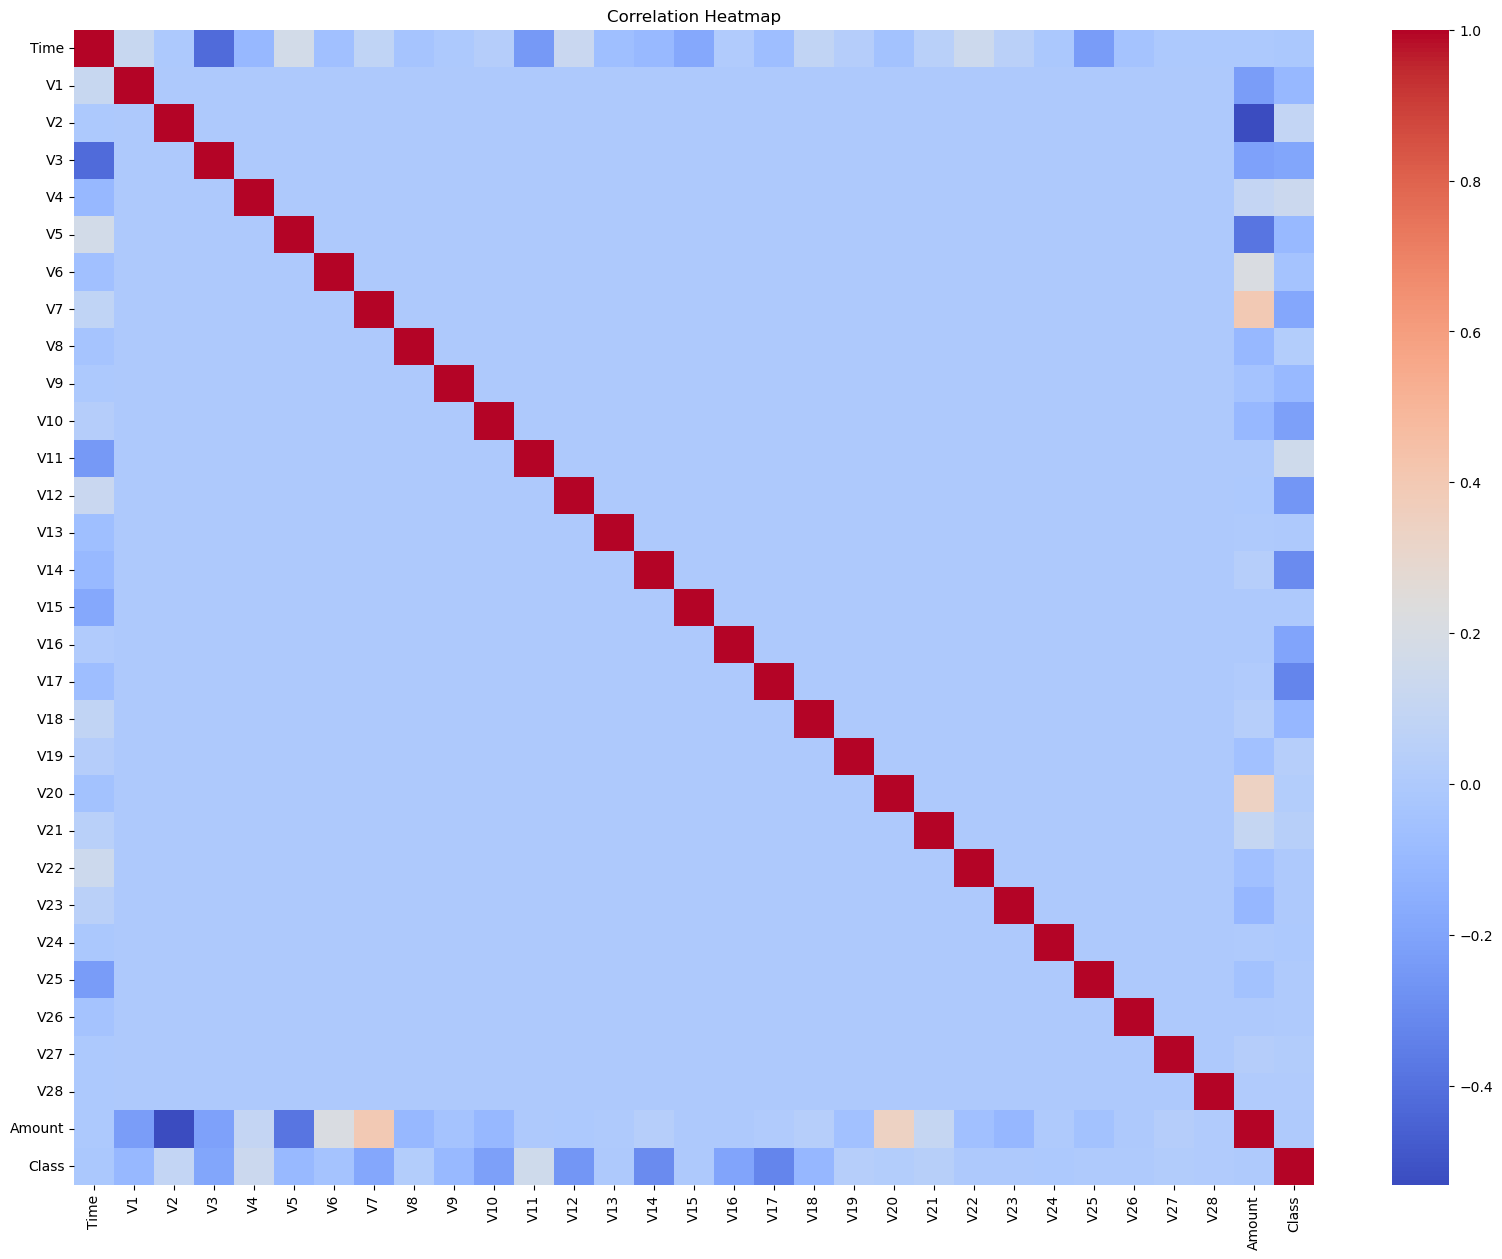

In [34]:
#Cell 9: Correlation Heatmap
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

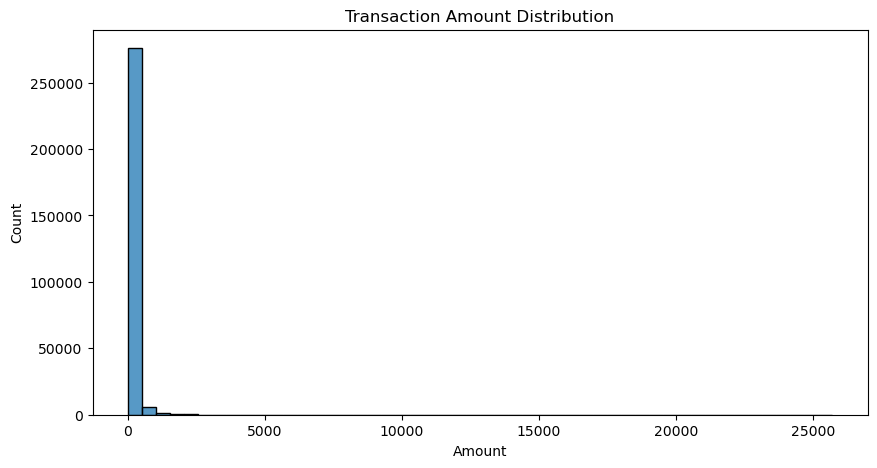

In [35]:
#Cell 10: Transaction Amount Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

In [36]:
#Cell 11: Scale Time and Amount
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

In [37]:
#Cell 12: Drop Old Columns
df.drop(['Time', 'Amount'], axis=1, inplace=True)

In [38]:
#Cell 13: Define Features and Target
X = df.drop('Class', axis=1)
y = df['Class']

In [39]:
#Cell 14: Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [40]:
#Cell 15: Check New Class Distribution
print(y_resampled.value_counts())

Class
0    284315
1    284315
Name: count, dtype: int64


In [41]:
#Cell 16: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [42]:
#Cell 17: Logistic Regression Model
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [43]:
#Cell 18: Logistic Regression Evaluation
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))
print("ROC AUC:", roc_auc_score(y_test, lr_pred))

Logistic Regression
Accuracy: 0.9489035049153228
Precision: 0.9743737135863821
Recall: 0.9222655153046897
F1 Score: 0.9476038050583833
ROC AUC: 0.9489565461986004


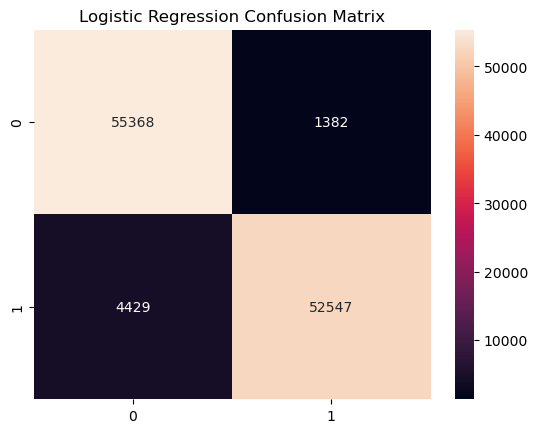

In [44]:
#Cell 19: Logistic Regression Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [45]:
#Cell 20: Decision Tree Model
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

In [46]:
#Cell 21: Decision Tree Evaluation
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))
print("ROC AUC:", roc_auc_score(y_test, dt_pred))

Decision Tree
Accuracy: 0.9984084554103723
Precision: 0.9977563934023943
Recall: 0.9990697837686043
F1 Score: 0.9984126566514948
ROC AUC: 0.9984071385803374


In [50]:
#Cell 22: Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [51]:
#Cell 23: Random Forest Evaluation
print("Random Forest Results\n")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_pred))

Random Forest Results

Accuracy : 0.9891141867295078
Precision: 0.9978385137549125
Recall   : 0.9803952541420949
F1 Score : 0.9890399801692694
ROC AUC  : 0.9891315477758934


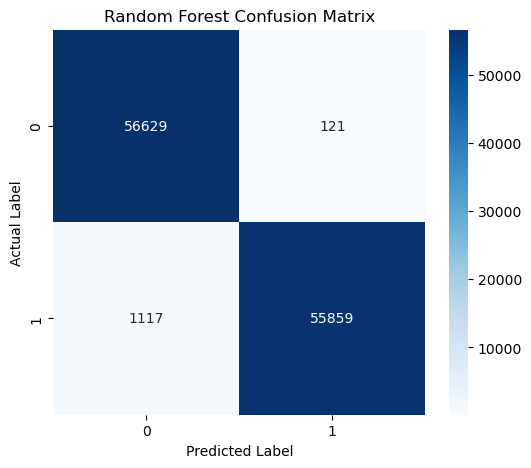

In [52]:
#Cell 24: Random Forest Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [53]:
#Cell 25: Classification Report
print("Classification Report:\n")
print(classification_report(y_test, rf_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     56750
           1       1.00      0.98      0.99     56976

    accuracy                           0.99    113726
   macro avg       0.99      0.99      0.99    113726
weighted avg       0.99      0.99      0.99    113726



In [54]:
#Cell 26: Model Comparison Table
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, lr_pred),
        roc_auc_score(y_test, dt_pred),
        roc_auc_score(y_test, rf_pred)
    ]

})
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.948904,0.974374,0.922266,0.947604,0.948957
1,Decision Tree,0.998408,0.997756,0.999070,0.998413,0.998407
2,Random Forest,0.989114,0.997839,0.980395,0.989040,0.989132


In [55]:
#Cell 27: Best Model Selection
best_model = results.sort_values(
    by='Recall',
    ascending=False
)
print("Best Performing Model:\n")
best_model.head(1)

Best Performing Model:



,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
1,Decision Tree,0.998408,0.997756,0.99907,0.998413,0.998407


In [56]:
#Cell 28: Feature Importance
importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': importance

})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance.head(10)

,Feature,Importance
13,V14,0.286712
3,V4,0.143627
16,V17,0.124648
2,V3,0.061798
9,V10,0.060925
1,V2,0.056136
10,V11,0.052651
15,V16,0.041338
6,V7,0.037317
11,V12,0.024494


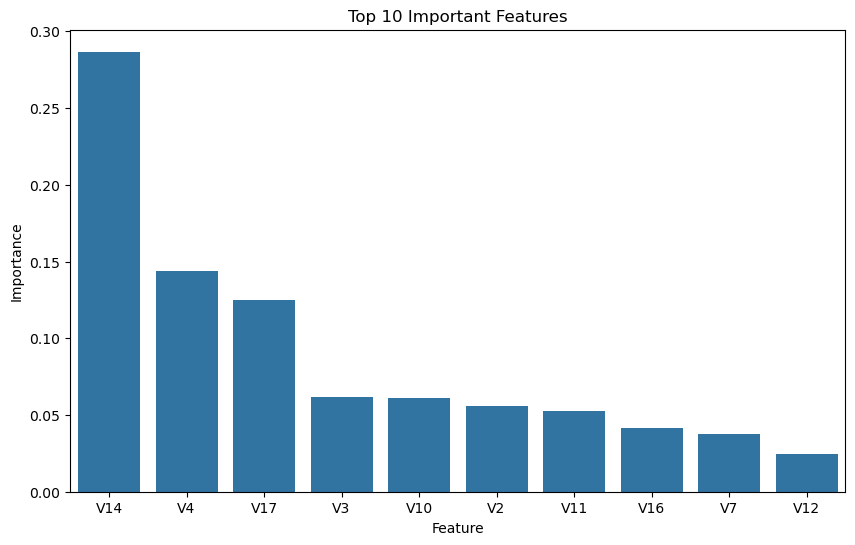

In [58]:
#Cell 29: Feature Importance Graph
plt.figure(figsize=(10,6))
sns.barplot(
    x='Feature',
    y='Importance',
    data=feature_importance.head(10)
)
plt.title("Top 10 Important Features")
plt.show()

In [59]:
#Cell 30: Final Conclusion
print("Project Completed Successfully")
print("\nBest Model Based on Recall:\n")
print(best_model.head(1))
print("\nComplete Model Comparison:\n")
print(results)

Project Completed Successfully

Best Model Based on Recall:

           Model  Accuracy  Precision   Recall  F1 Score   ROC AUC
1  Decision Tree  0.998408   0.997756  0.99907  0.998413  0.998407

Complete Model Comparison:

                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.948904   0.974374  0.922266  0.947604  0.948957
1        Decision Tree  0.998408   0.997756  0.999070  0.998413  0.998407
2        Random Forest  0.989114   0.997839  0.980395  0.989040  0.989132
